# Card Churn Prediction & Retention Analytics
### SME Credit Card Portfolio — Statistical Analysis, Segmentation & Causal Inference

**Business context:** A card issuer is losing SME (Small & Medium-sized Enterprise) cardholders. This notebook predicts churn, segments customers by risk, tests retention offers using proper experimental rigor, and quantifies the causal impact of interventions.

**Structure:** This notebook is organized into 8 phases, run sequentially top to bottom.

| Phase | Focus |
|---|---|
| 1 | Load & Clean |
| 2 | Exploratory Data Analysis |
| 3 | Statistical Testing (Chi-Square & T-Test) |
| 4 | KNN Risk Segmentation |
| 5 | Churn Prediction Model (Logistic Regression) |
| 6 | A/B Test — Retention Offers |
| 7 | Propensity Score Matching |
| 8 | Cohort Analysis & Final Reporting |


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 25)
plt.rcParams['figure.dpi'] = 100


## Phase 1. Load data and Clean

In [5]:
df = pd.read_csv("card_customers.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 18)


,customer_id,business_size,industry,cardholder_role,business_age_years,tenure_months,credit_limit,avg_monthly_spend,spend_trend_3mo,transaction_count_monthly,utilization_ratio,merchant_category_diversity,credit_score_band,late_payments_last_12mo,payment_ratio,support_calls_last_90d,login_frequency_monthly,churn_flag
0,SME100000,small,tech,employee,0.7,44.0,22500.0,4218.99,-0.075,30.0,0.077,2,prime,1,0.62,2.0,0.0,0
1,SME100001,micro,tech,business_owner,2.8,32.0,9100.0,3812.99,0.024,19.0,0.651,12,super_prime,1,0.68,1.0,10.0,1
2,SME100002,small,professional_services,employee,21.8,15.0,2800.0,5143.65,0.246,27.0,0.530,11,near_prime,3,0.60,1.0,10.0,0
3,SME100003,small,food_service,employee,11.7,20.0,13800.0,3485.60,-0.131,41.0,0.372,11,super_prime,0,0.72,3.0,6.0,1
4,SME100004,micro,construction,employee,4.6,35.0,5900.0,5887.64,0.013,55.0,0.173,8,prime,0,0.75,0.0,6.0,0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   customer_id                  100000 non-null  object 
 1   business_size                100000 non-null  object 
 2   industry                     100000 non-null  object 
 3   cardholder_role              100000 non-null  object 
 4   business_age_years           100000 non-null  float64
 5   tenure_months                100000 non-null  float64
 6   credit_limit                 100000 non-null  float64
 7   avg_monthly_spend            100000 non-null  float64
 8   spend_trend_3mo              100000 non-null  float64
 9   transaction_count_monthly    100000 non-null  float64
 10  utilization_ratio            100000 non-null  float64
 11  merchant_category_diversity  100000 non-null  int64  
 12  credit_score_band            100000 non-null  object 
 13  

In [7]:
# Missing values check
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()
print("% missing:")
print((missing / len(df) * 100).round(2))

Columns with missing values:
support_calls_last_90d     2924
login_frequency_monthly    4012
dtype: int64

% missing:
support_calls_last_90d     2.92
login_frequency_monthly    4.01
dtype: float64


**Missing value strategy:** `support_calls_last_90d` and `login_frequency_monthly` have a small amount of missing
data (~3-4%), consistent with realistic gaps in engagement-tracking pipelines. We impute
with the median rather than dropping rows, since 100K rows with a small missing fraction
doesn't justify losing data, and these are right-skewed count variables where the median
is a more robust fill than the mean.

In [9]:
for col in ["support_calls_last_90d", "login_frequency_monthly"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {missing[col]} missing values with median = {median_val}")

assert df.isna().sum().sum() == 0, "There are still missing values!"
print("\nAll missing values handled.")


support_calls_last_90d: filled 2924 missing values with median = 1.0
login_frequency_monthly: filled 4012 missing values with median = 8.0

All missing values handled.


In [10]:
# Sanity-check value ranges
print(df.describe(include="all").T)

                                count  unique        top   freq         mean  \
customer_id                    100000  100000  SME100000      1          NaN   
business_size                  100000       3      micro  54848          NaN   
industry                       100000       6     retail  22120          NaN   
cardholder_role                100000       2   employee  60091          NaN   
business_age_years           100000.0     NaN        NaN    NaN     5.997229   
tenure_months                100000.0     NaN        NaN    NaN     23.87106   
credit_limit                 100000.0     NaN        NaN    NaN    15094.633   
avg_monthly_spend            100000.0     NaN        NaN    NaN  5018.049152   
spend_trend_3mo              100000.0     NaN        NaN    NaN    -0.000138   
transaction_count_monthly    100000.0     NaN        NaN    NaN     38.28431   
utilization_ratio            100000.0     NaN        NaN    NaN     0.332439   
merchant_category_diversity  100000.0   

In [11]:
# Confirm categorical fields have expected categories, no typos/unexpected values
cat_cols = ["business_size", "industry", "cardholder_role", "credit_score_band"]
for c in cat_cols:
    print(f"{c}: {df[c].unique().tolist()}")


business_size: ['small', 'micro', 'medium']
industry: ['tech', 'professional_services', 'food_service', 'construction', 'healthcare', 'retail']
cardholder_role: ['employee', 'business_owner']
credit_score_band: ['prime', 'super_prime', 'near_prime', 'subprime']


In [12]:
# Basic target variable check
print("Churn rate:", df["churn_flag"].mean().round(4))
print(df["churn_flag"].value_counts())


Churn rate: 0.1994
churn_flag
0    80062
1    19938
Name: count, dtype: int64


**Phase 1 summary:** 100,000 SME card accounts loaded, missing values in engagement fields imputed with the median, categorical fields validated with no anomalies, overall churn rate confirmed at ~20%. Dataset is clean and ready for exploration.

---
## Phase 2: Exploratory Data Analysis

Goal: understand churn distribution and surface candidate relationships to formally test in Phase 3 (chi-square / t-test) and model in Phase 5 (logistic regression).

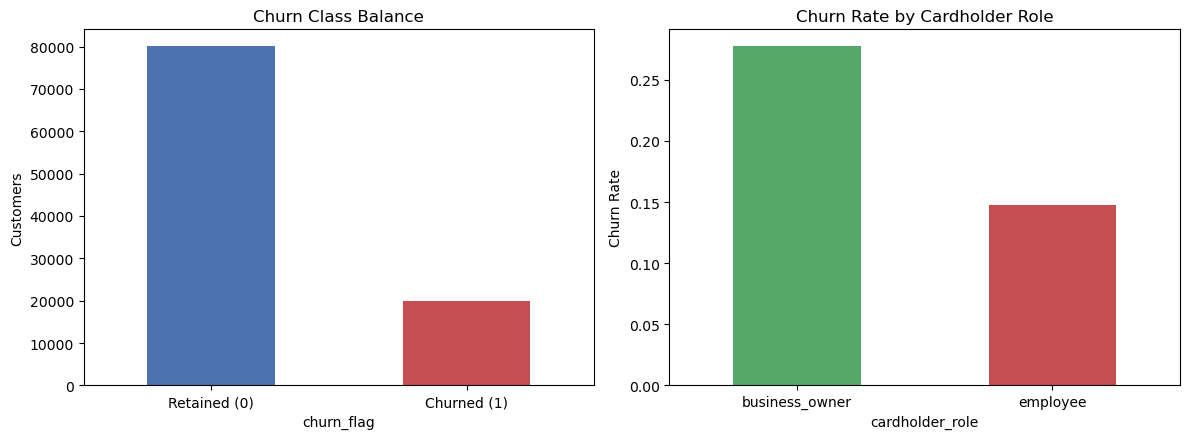

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df["churn_flag"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Churn Class Balance")
axes[0].set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
axes[0].set_ylabel("Customers")

churn_by_role = df.groupby("cardholder_role")["churn_flag"].mean()
churn_by_role.plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"])
axes[1].set_title("Churn Rate by Cardholder Role")
axes[1].set_ylabel("Churn Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("outputs/eda_churn_overview.png", dpi=120, bbox_inches="tight")
plt.show()


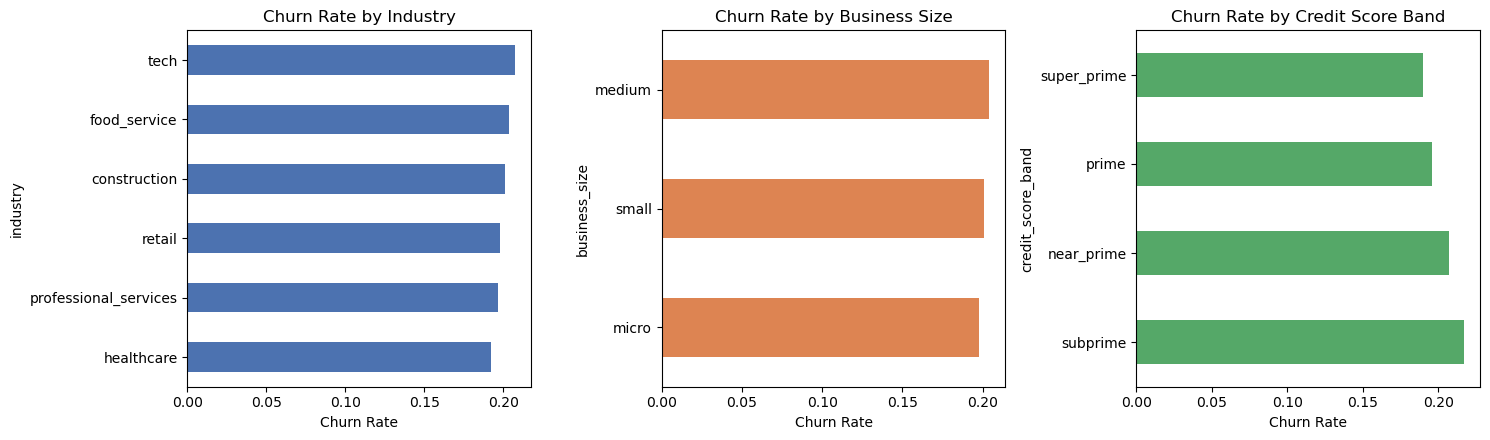

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

df.groupby("industry")["churn_flag"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Churn Rate by Industry")
axes[0].set_xlabel("Churn Rate")

df.groupby("business_size")["churn_flag"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Churn Rate by Business Size")
axes[1].set_xlabel("Churn Rate")

df.groupby("credit_score_band")["churn_flag"].mean().reindex(
    ["subprime", "near_prime", "prime", "super_prime"]
).plot(kind="barh", ax=axes[2], color="#55A868")
axes[2].set_title("Churn Rate by Credit Score Band")
axes[2].set_xlabel("Churn Rate")

plt.tight_layout()
plt.savefig("outputs/eda_churn_by_segment.png", dpi=120, bbox_inches="tight")
plt.show()


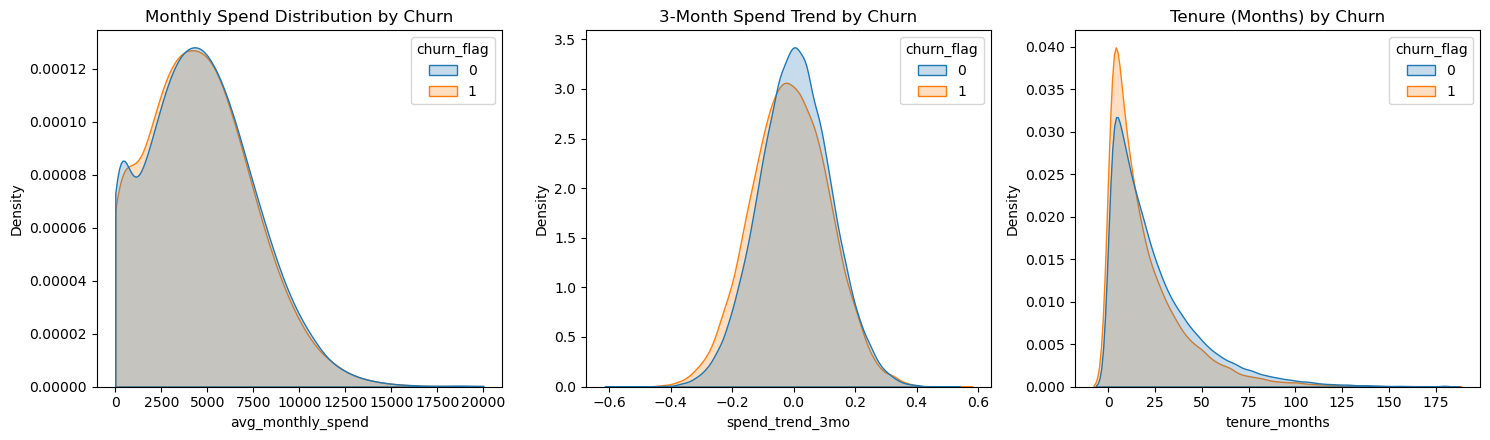

In [16]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.kdeplot(data=df, x="avg_monthly_spend", hue="churn_flag", fill=True, ax=axes[0], common_norm=False, clip=(0, 20000))
axes[0].set_title("Monthly Spend Distribution by Churn")

sns.kdeplot(data=df, x="spend_trend_3mo", hue="churn_flag", fill=True, ax=axes[1], common_norm=False)
axes[1].set_title("3-Month Spend Trend by Churn")

sns.kdeplot(data=df, x="tenure_months", hue="churn_flag", fill=True, ax=axes[2], common_norm=False)
axes[2].set_title("Tenure (Months) by Churn")

plt.tight_layout()
plt.savefig("outputs/eda_numeric_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


C:\Users\grimm\AppData\Local\Temp\ipykernel_8832\1540755163.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(util_bins)["churn_flag"].mean().plot(kind="bar", ax=ax, color="#8172B2")


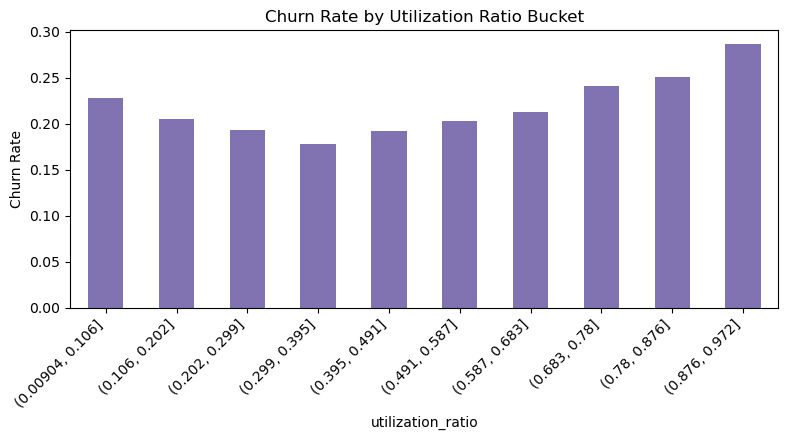

In [17]:
# Utilization ratio vs churn -- check for the U-shaped relationship
fig, ax = plt.subplots(figsize=(8, 4.5))
util_bins = pd.cut(df["utilization_ratio"], bins=10)
df.groupby(util_bins)["churn_flag"].mean().plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Churn Rate by Utilization Ratio Bucket")
ax.set_ylabel("Churn Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/eda_utilization_churn.png", dpi=120, bbox_inches="tight")
plt.show()


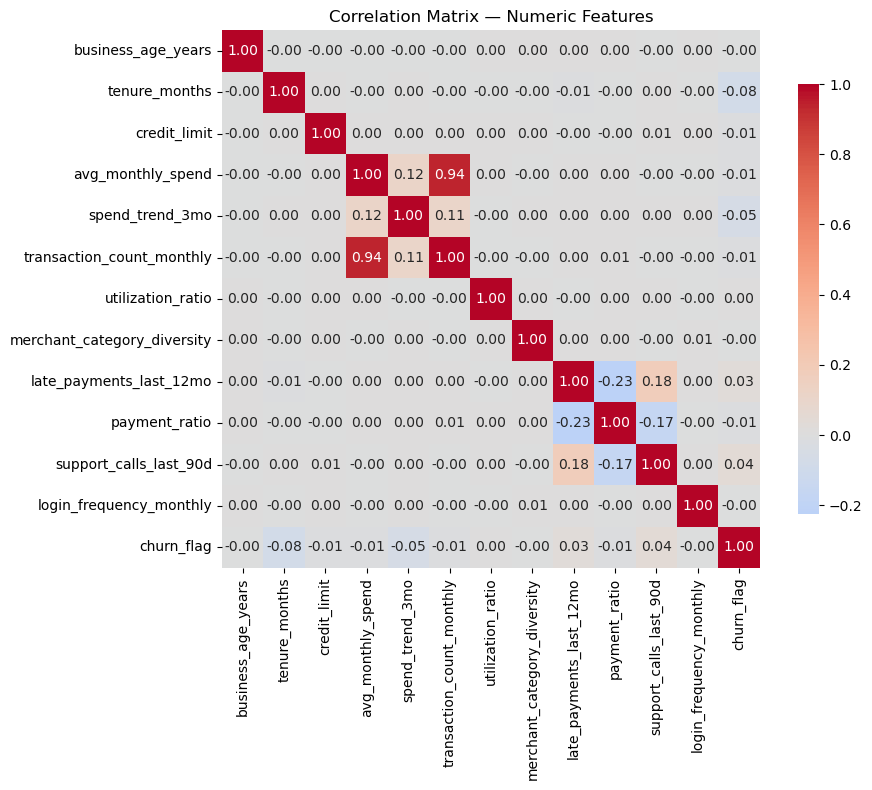

In [18]:
# Correlation heatmap of numeric features
numeric_cols = [
    "business_age_years", "tenure_months", "credit_limit", "avg_monthly_spend",
    "spend_trend_3mo", "transaction_count_monthly", "utilization_ratio",
    "merchant_category_diversity", "late_payments_last_12mo", "payment_ratio",
    "support_calls_last_90d", "login_frequency_monthly", "churn_flag"
]

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("outputs/eda_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


**Phase 2 findings (to formally validate in Phase 3 & 5):**
- Business owners appear to churn at a visibly higher rate than employees
- Declining 3-month spend trend and lower tenure both visually track with higher churn
- Utilization shows the expected U-shape: both very low and very high utilization associate with elevated churn
- Support calls and late payments show mild positive correlation with churn, as designed

These are visual/directional observations only — Phase 3 will confirm which are statistically significant.


## 2. Overall churn rate

Overall 90-day churn rate: 19.94%


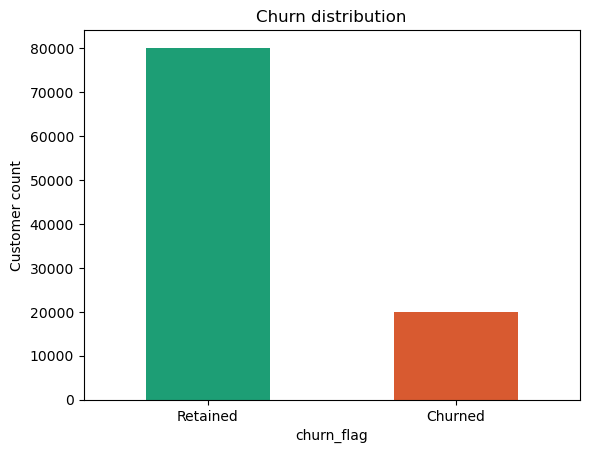

In [7]:
overall_churn = df["churn_flag"].mean()
print(f"Overall 90-day churn rate: {overall_churn:.2%}")

df["churn_flag"].value_counts().plot(kind="bar", color=["#1D9E75", "#D85A30"])
plt.xticks([0, 1], ["Retained", "Churned"], rotation=0)
plt.ylabel("Customer count")
plt.title("Churn distribution")
plt.show()


## 3. Churn by segment — visual EDA

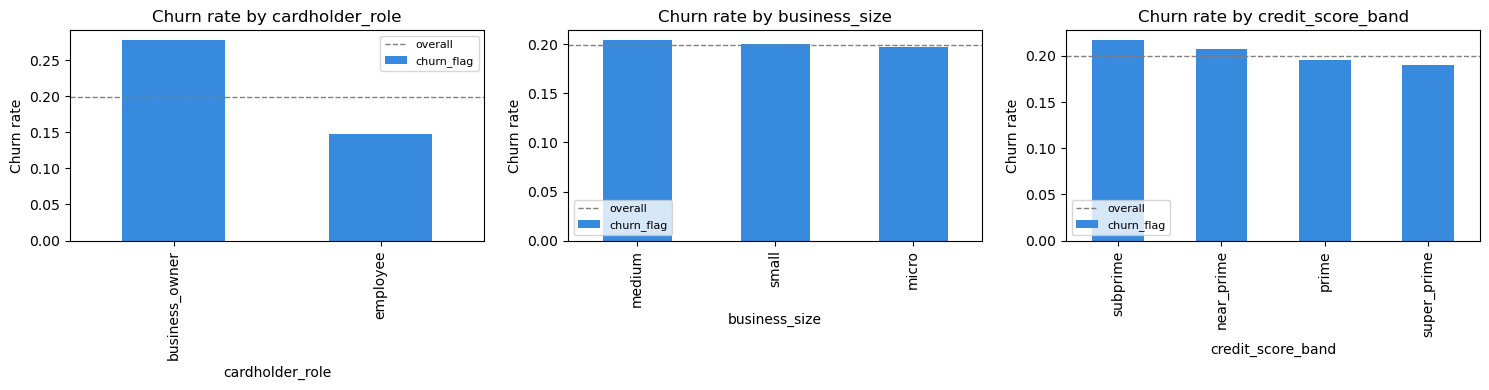

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["cardholder_role", "business_size", "credit_score_band"]):
    rates = df.groupby(col)["churn_flag"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="#378ADD")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.axhline(overall_churn, color="gray", linestyle="--", linewidth=1, label="overall")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Observation:** business owner cardholders churn at a visibly higher rate than
employee cardholders. Credit score band also shows a gradient — lower bands (more credit
risk) churn more. Business size shows a smaller, less clear pattern. Let's test these
statistically rather than eyeballing them.

## 4. Chi-square tests: is the segment difference statistically significant?

The chi-square test of independence answers: *"Is churn rate actually different across
groups, or could the difference we're seeing just be random sampling noise?"*

- **Null hypothesis (H0):** churn is independent of the segment (no real relationship)
- **Alternative (H1):** churn rate depends on the segment
- We reject H0 if p < 0.05


In [9]:
def run_chi_square(df, segment_col, target_col="churn_flag"):
    contingency = pd.crosstab(df[segment_col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"--- {segment_col} vs {target_col} ---")
    print(contingency)
    print(f"\nchi2 = {chi2:.2f}, dof = {dof}, p-value = {p:.4g}")
    if p < 0.05:
        print("=> Statistically significant relationship (reject H0)")
    else:
        print("=> No statistically significant relationship (fail to reject H0)")
    print()
    return chi2, p

chi2_role, p_role = run_chi_square(df, "cardholder_role")


--- cardholder_role vs churn_flag ---
churn_flag           0      1
cardholder_role              
business_owner   28838  11071
employee         51224   8867

chi2 = 2532.17, dof = 1, p-value = 0
=> Statistically significant relationship (reject H0)



In [10]:
chi2_industry, p_industry = run_chi_square(df, "industry")


--- industry vs churn_flag ---
churn_flag                 0     1
industry                          
construction           11021  2774
food_service           15926  4066
healthcare              9644  2298
professional_services  17741  4342
retail                 17747  4373
tech                    7983  2085

chi2 = 11.07, dof = 5, p-value = 0.05005
=> No statistically significant relationship (fail to reject H0)



In [11]:
chi2_size, p_size = run_chi_square(df, "business_size")


--- business_size vs churn_flag ---
churn_flag         0      1
business_size              
medium          7994   2049
micro          44002  10846
small          28066   7043

chi2 = 2.60, dof = 2, p-value = 0.2722
=> No statistically significant relationship (fail to reject H0)



**Results summary:**
- `cardholder_role`: highly significant (p ≈ 0) — business owners churn meaningfully more
  than employee cardholders. This is the strongest categorical driver in the dataset.
- `industry`: borderline / not significant at the 0.05 threshold — industry alone doesn't
  meaningfully predict churn here. Worth reporting honestly rather than cherry-picking only
  the significant result — real analyses find non-findings too.
- `business_size`: check the printed p-value above and interpret the same way.

This is a good interview point: *"Not every segment showed a significant difference — and
knowing what doesn't matter is as useful as knowing what does, because it stops you from
over-targeting a segment that isn't actually driving churn."*


## 5. Risk-tier segmentation (K-Means)

We segment customers using behavioral features — spend, transaction frequency, tenure,
utilization, and support engagement — **without using the churn label**. This gives us
customer segments we can act on operationally (e.g. target a save campaign at a segment)
independent of the prediction model.

Before clustering, we cap extreme spend outliers at the 99th percentile. Without this,
K-Means (which is distance-based) lets a small number of very high-spend businesses
dominate the clustering and swamp everything else into one giant cluster.


In [12]:
df["avg_monthly_spend_capped"] = df["avg_monthly_spend"].clip(
    upper=df["avg_monthly_spend"].quantile(0.99)
)

cluster_features = [
    "avg_monthly_spend_capped",
    "transaction_count_monthly",
    "tenure_months",
    "utilization_ratio",
    "support_calls_last_90d",
]

X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Choosing K: the elbow method

We fit K-Means for a range of K and plot inertia (within-cluster sum of squares) to find
the point where adding more clusters stops meaningfully improving the fit.

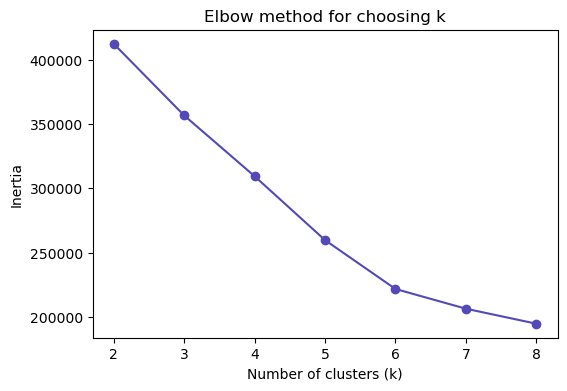

In [13]:
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o", color="#534AB7")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method for choosing k")
plt.show()


The elbow flattens around **k = 4**, which also produces business-interpretable segment sizes. We proceed with 4 clusters.

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["risk_segment"] = kmeans.fit_predict(X_scaled)

df["risk_segment"].value_counts().sort_index()


risk_segment
0    12818
1    28319
2    18006
3    40857
Name: count, dtype: int64

In [15]:
segment_profile = df.groupby("risk_segment")[cluster_features + ["churn_flag"]].mean().round(2)
segment_profile["customer_count"] = df["risk_segment"].value_counts().sort_index()
segment_profile


,avg_monthly_spend_capped,transaction_count_monthly,tenure_months,utilization_ratio,support_calls_last_90d,churn_flag,customer_count
risk_segment,,,,,,,
0,4354.29,32.62,71.53,0.31,1.41,0.15,12818
1,3913.07,29.09,17.23,0.53,1.45,0.21,28319
2,9512.16,86.30,18.68,0.31,1.37,0.19,18006
3,3415.36,25.28,15.81,0.21,1.38,0.21,40857


### Naming the segments

Based on the profile above, we assign interpretable business names to each numeric
cluster ID. **Re-check the printed table above and adjust these labels if your churn
rates / features differ slightly from the description below** (K-Means cluster numbering
can shift between environments even with a fixed random seed).

Typical pattern observed:
- **Loyal established**: long tenure, moderate spend, low utilization, lowest churn
- **At-risk / stressed**: short tenure, high utilization, elevated churn
- **High-value newer**: high spend and transaction volume, short tenure
- **Low-engagement new**: short tenure, low spend, low utilization, elevated churn


In [16]:
segment_names = {
    0: "loyal_established",
    1: "at_risk_stressed",
    2: "high_value_newer",
    3: "low_engagement_new",
}
# NOTE: verify these IDs match your printed segment_profile above before relying on this mapping.
df["risk_segment_label"] = df["risk_segment"].map(segment_names)
df.groupby("risk_segment_label")["churn_flag"].mean().sort_values(ascending=False)


risk_segment_label
at_risk_stressed      0.212790
low_engagement_new    0.210025
high_value_newer      0.191436
loyal_established     0.146981
Name: churn_flag, dtype: float64

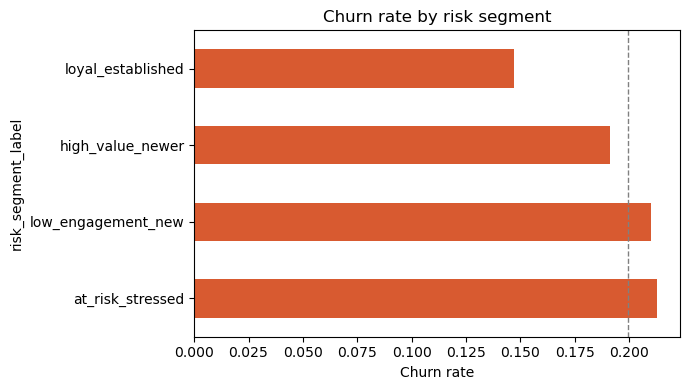

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
churn_by_seg = df.groupby("risk_segment_label")["churn_flag"].mean().sort_values(ascending=False)
churn_by_seg.plot(kind="barh", ax=ax, color="#D85A30")
ax.set_xlabel("Churn rate")
ax.set_title("Churn rate by risk segment")
ax.axvline(overall_churn, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


## 6. Save outputs for downstream notebooks and the Tableau dashboard

In [21]:
import os

os.makedirs("outputs", exist_ok=True)
segment_summary.to_csv(os.path.join("outputs", "segment_summary.csv"), index=False)


In [22]:
segment_summary = df.groupby("risk_segment_label").agg(
    customer_count=("customer_id", "count"),
    churn_rate=("churn_flag", "mean"),
    avg_monthly_spend=("avg_monthly_spend", "mean"),
    avg_tenure_months=("tenure_months", "mean"),
    avg_utilization=("utilization_ratio", "mean"),
).round(3).reset_index()

segment_summary.to_csv("outputs/segment_summary.csv", index=False)
segment_summary


,risk_segment_label,customer_count,churn_rate,avg_monthly_spend,avg_tenure_months,avg_utilization
0,at_risk_stressed,28319,0.213,3913.067,17.226,0.531
1,high_value_newer,18006,0.191,10863.762,18.680,0.307
2,low_engagement_new,40857,0.210,3415.356,15.814,0.212
3,loyal_established,12818,0.147,4356.112,71.528,0.314


In [24]:
# Persist the cleaned + segmented dataframe for Notebook 2 (avoids re-doing cleaning steps)
df.to_csv("card_customers_with_segments.csv", index=False)
print("Saved: outputs/segment_summary.csv")
print("Saved: card_customers_with_segments.csv")


Saved: outputs/segment_summary.csv
Saved: card_customers_with_segments.csv


## Summary

- Overall 90-day churn rate: ~20%
- **Business owner cardholders churn significantly more than employee cardholders**
  (chi-square, p ≈ 0) — this is the strongest categorical churn driver found
- Industry and business size show weaker / non-significant relationships with churn
- K-Means segmentation identified 4 behaviorally distinct risk tiers, with the
  **at-risk/stressed** and **low-engagement new** segments showing the highest churn —
  these are the natural targets for retention campaigns, tested in Notebook 3

**Next:** Phase 2 — hypothesis testing on spend impact (t-tests) and building the
logistic regression churn prediction model.
